<a href="https://colab.research.google.com/github/shuchivardan/Shuchi_V_Portfolio/blob/main/Meridian_implementation_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
pip install google-meridian

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

import tensorflow as tf
import meridian as meridian

print(tf.__version__)
print(meridian.__version__)

2.20.0
1.6.1


In [2]:
# Adding Data

np.random.seed(42)

# ── TIME DIMENSION ────────────────────────────────────────────────────────────
n     = 156
weeks = pd.date_range(start="2022-01-03", periods=n, freq="W-MON")

# ── B2B SEASONALITY INDEX ─────────────────────────────────────────────────────
month = pd.DatetimeIndex(weeks).month
quarter_end_weeks = (
    pd.DatetimeIndex(weeks).month.isin([3, 6, 9, 12]) &
    (pd.DatetimeIndex(weeks).day >= 15)
)

seasonality_index = np.where(month.isin([10, 11, 12]), 1.35,
                    np.where(month.isin([1, 2, 3]),     0.75,
                    np.where(month.isin([7, 8]),         0.85,
                    1.0)))

quarter_end_boost = quarter_end_weeks.astype(float) * 0.15

# ── HELPER: channel spend with independent noise per channel ──────────────────
def make_spend(base_low, base_high, season_weight, noise_low=0.75, noise_high=1.25):
    base          = np.random.uniform(base_low, base_high, n)
    season_effect = 1 + season_weight * (seasonality_index - 1)
    channel_noise = np.random.uniform(noise_low, noise_high, n)
    return base * season_effect * channel_noise

# ── MEDIA SPEND ───────────────────────────────────────────────────────────────
paid_search_brand    = make_spend(80_000,  140_000, season_weight=0.9)
paid_search_nonbrand = make_spend(60_000,  120_000, season_weight=0.8)
linkedin             = make_spend(120_000, 280_000, season_weight=0.7)
programmatic_display = make_spend(50_000,  130_000, season_weight=0.5)
ctv_streaming        = make_spend(90_000,  200_000, season_weight=0.6)
sponsored_content    = make_spend(30_000,   80_000, season_weight=0.4)
trade_publications   = make_spend(20_000,   60_000, season_weight=0.1)
events_webinars      = make_spend(40_000,  150_000, season_weight=0.8,
                                  noise_low=0.5, noise_high=1.5)

# ── ADSTOCK FUNCTION ──────────────────────────────────────────────────────────
def apply_adstock(spend, decay_rate):
    adstocked    = np.zeros(len(spend))
    adstocked[0] = spend[0]
    for t in range(1, len(spend)):
        adstocked[t] = spend[t] + decay_rate * adstocked[t-1]
    return adstocked

# ── APPLY ADSTOCK ─────────────────────────────────────────────────────────────
ps_brand_adstocked    = apply_adstock(paid_search_brand,    decay_rate=0.2)
ps_nonbrand_adstocked = apply_adstock(paid_search_nonbrand, decay_rate=0.3)
linkedin_adstocked    = apply_adstock(linkedin,             decay_rate=0.6)
display_adstocked     = apply_adstock(programmatic_display, decay_rate=0.5)
ctv_adstocked         = apply_adstock(ctv_streaming,        decay_rate=0.65)
content_adstocked     = apply_adstock(sponsored_content,    decay_rate=0.55)
trade_adstocked       = apply_adstock(trade_publications,   decay_rate=0.45)
events_adstocked      = apply_adstock(events_webinars,      decay_rate=0.35)

# ── TRUE PIPELINE ─────────────────────────────────────────────────────────────
# Baseline calculated to give exactly 76% of total pipeline
# Formula: baseline = (0.76 * non_baseline_mean) / 0.24
# Non-baseline mean = media contribution + seasonality = $4,172,508

baseline = 13_212_942

pipeline = (
    baseline
    + 4.80 * ps_brand_adstocked      # true ROI — original values
    + 2.90 * ps_nonbrand_adstocked
    + 1.85 * linkedin_adstocked
    + 0.95 * display_adstocked
    + 1.10 * ctv_adstocked
    + 2.20 * content_adstocked
    + 1.65 * trade_adstocked
    + 3.10 * events_adstocked
    + seasonality_index * 800_000
    + quarter_end_boost * 1_200_000
    + np.random.normal(0, 350_000, n)
)

# ── ASSEMBLE DATAFRAME ────────────────────────────────────────────────────────
df = pd.DataFrame({
    'week'                : weeks,
    'pipeline_usd'        : pipeline.round(0),
    'paid_search_brand'   : paid_search_brand.round(0),
    'paid_search_nonbrand': paid_search_nonbrand.round(0),
    'linkedin'            : linkedin.round(0),
    'programmatic_display': programmatic_display.round(0),
    'ctv_streaming'       : ctv_streaming.round(0),
    'sponsored_content'   : sponsored_content.round(0),
    'trade_publications'  : trade_publications.round(0),
    'events_webinars'     : events_webinars.round(0),
})

channel_cols = ['paid_search_brand', 'paid_search_nonbrand', 'linkedin',
                'programmatic_display', 'ctv_streaming', 'sponsored_content',
                'trade_publications', 'events_webinars']

# ── VERIFY ────────────────────────────────────────────────────────────────────
print(f'Dataset shape:      {df.shape}')
print(f'Pipeline mean:      ${df.pipeline_usd.mean():,.0f}')
print(f'Pipeline range:     ${df.pipeline_usd.min():,.0f} — ${df.pipeline_usd.max():,.0f}')
print(f'True baseline %:    {baseline / df.pipeline_usd.mean() * 100:.1f}%')

Dataset shape:      (156, 10)
Pipeline mean:      $17,373,157
Pipeline range:     $15,795,508 — $19,513,599
True baseline %:    76.1%


In [3]:
np.random.seed(99)

# Brand GQV — driven by seasonality and demand shocks only
# No spend component — spend follows GQV, not the other way around
brand_gqv = (
    0.65 * seasonality_index
    + 0.35 * np.random.normal(1, 0.20, n)
)
brand_gqv = (brand_gqv / brand_gqv.mean())

# Generic GQV — category demand, slightly more volatile
generic_gqv = (
    0.60 * seasonality_index
    + 0.40 * np.random.normal(1, 0.25, n)
)
generic_gqv = (generic_gqv / generic_gqv.mean())

# Check correlations
print(f'brand_gqv vs paid_search_brand:      {np.corrcoef(brand_gqv, df.paid_search_brand)[0,1]:.2f}')
print(f'generic_gqv vs paid_search_nonbrand: {np.corrcoef(generic_gqv, df.paid_search_nonbrand)[0,1]:.2f}')
print(f'brand_gqv vs pipeline:               {np.corrcoef(brand_gqv, df.pipeline_usd)[0,1]:.2f}')
print(f'generic_gqv vs pipeline:             {np.corrcoef(generic_gqv, df.pipeline_usd)[0,1]:.2f}')

brand_gqv vs paid_search_brand:      0.59
generic_gqv vs paid_search_nonbrand: 0.36
brand_gqv vs pipeline:               0.74
generic_gqv vs pipeline:             0.65


In [4]:
# new implimentation needs GQV, hence generating synthetic GQV data

np.random.seed(99)

# Brand GQV — small spend component to maintain spend correlation
brand_gqv = (
    0.20 * (df['paid_search_brand'] / df['paid_search_brand'].mean())
    + 0.40 * seasonality_index
    + 0.40 * np.random.normal(1, 0.20, n)
)
brand_gqv = brand_gqv / brand_gqv.mean()

# Generic GQV
generic_gqv = (
    0.20 * (df['paid_search_nonbrand'] / df['paid_search_nonbrand'].mean())
    + 0.35 * seasonality_index
    + 0.45 * np.random.normal(1, 0.25, n)
)
generic_gqv = generic_gqv / generic_gqv.mean()

# Check correlations
print(f'brand_gqv vs paid_search_brand:      {np.corrcoef(brand_gqv, df.paid_search_brand)[0,1]:.2f}  (target: 0.55-0.70)')
print(f'generic_gqv vs paid_search_nonbrand: {np.corrcoef(generic_gqv, df.paid_search_nonbrand)[0,1]:.2f}  (target: 0.40-0.60)')
print(f'brand_gqv vs pipeline:               {np.corrcoef(brand_gqv, df.pipeline_usd)[0,1]:.2f}  (target: 0.30-0.50)')
print(f'generic_gqv vs pipeline:             {np.corrcoef(generic_gqv, df.pipeline_usd)[0,1]:.2f}  (target: 0.35-0.55)')

brand_gqv vs paid_search_brand:      0.74  (target: 0.55-0.70)
generic_gqv vs paid_search_nonbrand: 0.55  (target: 0.40-0.60)
brand_gqv vs pipeline:               0.72  (target: 0.30-0.50)
generic_gqv vs pipeline:             0.57  (target: 0.35-0.55)


In [5]:
# Creating Media Volume Synthetic data
np.random.seed(42)

# ── CLICKS: for search channels ───────────────────────────────────────────────
# CPC = cost per click (dollars per click)
# We add noise so clicks don't perfectly mirror spend week to week
# np.random.uniform(low, high, n) = random number between low and high for each week

brand_cpc    = np.random.uniform(6,  10, n)   # branded search cheaper — high intent, less competition
nonbrand_cpc = np.random.uniform(12, 20, n)   # nonbrand more expensive — competitive keywords

brand_clicks    = (df['paid_search_brand']    / brand_cpc).values
nonbrand_clicks = (df['paid_search_nonbrand'] / nonbrand_cpc).values

# ── IMPRESSIONS: for awareness channels ───────────────────────────────────────
# CPM = cost per thousand impressions
# impressions = (spend / CPM) * 1000

linkedin_cpm  = np.random.uniform(28, 45, n)   # LinkedIn is expensive — B2B premium
display_cpm   = np.random.uniform(4,  8,  n)   # programmatic display is cheap
ctv_cpm       = np.random.uniform(20, 35, n)   # CTV mid-range
content_cpm   = np.random.uniform(15, 25, n)   # sponsored content
trade_cpm     = np.random.uniform(20, 35, n)   # trade publications

linkedin_imps  = ((df['linkedin']             / linkedin_cpm) * 1000 /20).values
display_imps   = ((df['programmatic_display'] / display_cpm)  * 1000 / 15).values
ctv_imps       = ((df['ctv_streaming']        / ctv_cpm)      * 1000 / 18).values
content_imps   = ((df['sponsored_content']    / content_cpm)  * 1000 / 12).values
trade_imps     = ((df['trade_publications']   / trade_cpm)    * 1000 / 10).values

# ── EVENTS: for organic channel ───────────────────────────────────────────────
# Events/webinars = number of events run that week
# Most weeks 0-2 events, occasional 3-4 during busy periods
events_count = np.random.poisson(lam=1.2, size=n).astype(float)

# ── QUICK SANITY CHECK ────────────────────────────────────────────────────────
print('Media volume ranges:')
print(f'  brand clicks/week:      {brand_clicks.min():.0f} – {brand_clicks.max():.0f}')
print(f'  nonbrand clicks/week:   {nonbrand_clicks.min():.0f} – {nonbrand_clicks.max():.0f}')
print(f'  linkedin imps/week:     {linkedin_imps.min():.0f} – {linkedin_imps.max():.0f}')
print(f'  display imps/week:      {display_imps.min():.0f} – {display_imps.max():.0f}')
print(f'  ctv imps/week:          {ctv_imps.min():.0f} – {ctv_imps.max():.0f}')
print(f'  events/week:            {events_count.min():.0f} – {events_count.max():.0f}')

Media volume ranges:
  brand clicks/week:      8150 – 22506
  nonbrand clicks/week:   2441 – 12076
  linkedin imps/week:     106075 – 540696
  display imps/week:      392568 – 2744866
  ctv imps/week:          112251 – 656287
  events/week:            0 – 5


In [6]:
print(f'  content imps/week:      {content_imps.min():.0f} – {content_imps.max():.0f}')
print(f'  trade imps/week:        {trade_imps.min():.0f} – {trade_imps.max():.0f}')

  content imps/week:      93249 – 504504
  trade imps/week:        56057 – 319856


In [7]:
# add GQV cols to the dataframe
df['brand_gqv']   = brand_gqv
df['generic_gqv'] = generic_gqv

In [8]:
#define channel cols
channel_cols = ['paid_search_brand', 'paid_search_nonbrand', 'linkedin',
                'programmatic_display', 'ctv_streaming', 'sponsored_content',
                'trade_publications', 'events_webinars']

gqv_cols = ['brand_gqv', 'generic_gqv']

kpi_col = ['pipeline_usd']

#add media volume colums to the dataframe as well
df = df.assign(**{
    'brand_clicks'    : brand_clicks,
    'nonbrand_clicks' : nonbrand_clicks,
    'linkedin_imps'   : linkedin_imps,
    'display_imps'    : display_imps,
    'ctv_imps'        : ctv_imps,
    'content_imps'    : content_imps,
    'trade_imps'      : trade_imps,
    'events_count'    : events_count
})
df.columns
#df.shape

corr_cols = channel_cols + gqv_cols + kpi_col
corr_df = df[corr_cols]

<Axes: >

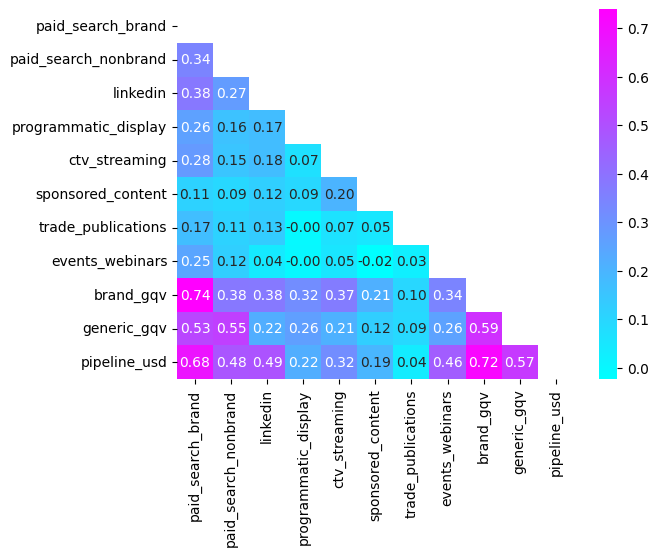

In [9]:
# printing correlation
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))

corr_df = df[corr_cols]
sns.heatmap(corr_df.corr(), cmap='cool', mask = mask, annot=True, fmt = '.2f')



In [10]:

# spend share check to confirm nothing less than 3%
sum_df = df[channel_cols].sum()
total = sum_df.sum()
sum_df = (sum_df.sort_values())/total *100
print(sum_df)

print(total)

trade_publications       4.884272
sponsored_content        6.700861
paid_search_nonbrand    11.008797
programmatic_display    11.361281
events_webinars         11.532897
paid_search_brand       13.323172
ctv_streaming           17.580720
linkedin                23.608000
dtype: float64
127089758.0


In [11]:
# click/impression/event count share check to confirm nothing less than 3%
clicks_col = ['brand_clicks', 'nonbrand_clicks']
imp_cols = ['linkedin_imps', 'display_imps', 'ctv_imps', 'content_imps','trade_imps']
event_col = ['events_count']

clicks_share = (df[clicks_col].sum()/df[clicks_col].sum().sum()*100).sort_values(ascending=False)
print(clicks_share)

imp_share = (df[imp_cols].sum()/df[imp_cols].sum().sum()*100).sort_values(ascending=False)
print(f'\n{imp_share}')


brand_clicks       70.744931
nonbrand_clicks    29.255069
dtype: float64

display_imps     52.745500
ctv_imps         14.863186
linkedin_imps    13.398727
content_imps     11.678253
trade_imps        7.314334
dtype: float64


In [12]:
# Define each column in the data per meridian standards
# Paid Channel
# Organic Channel
# Media Volume
# Media Spend
# Non Media Treatments (eg. Promotions, Product Launches)
# Control (confounders like market dynamics, competitor activity, GQV, Economic Indicators)
# KPI
# Revenue per KPI (in case KPI is not revenue)
# Geo ()

# ── MASTER VARIABLE DEFINITIONS ───────────────────────────────────────────────

# These lists define what goes into each Meridian data type
# Order matters — must be consistent across all three paid lists
paid_channels = ['paid_search_brand', 'paid_search_nonbrand', 'linkedin',
                 'programmatic_display', 'ctv_streaming',
                 'sponsored_content', 'trade_publications']

# Organic channel
organic_channels = ['events_webinars']

# Media Vol Cols - must be same order as paid_channels
media_vol_cols = ['brand_clicks', 'nonbrand_clicks', 'linkedin_imps',
                  'display_imps', 'ctv_imps', 'content_imps', 'trade_imps']

# Media Spend - must be same order as paid_channels
media_spend_cols = ['paid_search_brand', 'paid_search_nonbrand', 'linkedin',
                    'programmatic_display', 'ctv_streaming',
                    'sponsored_content', 'trade_publications']
# Organic Vol Col
organic_vol_cols = ['events_count']

# Controls
control_vars = ['brand_gqv', 'generic_gqv']

# KPI
kpi_col = 'pipeline_usd'

geos = ['national']
times_str = pd.date_range('2022-01-03', periods=156, freq='W-MON') \
              .strftime('%Y-%m-%d') \
              .tolist()


print('Paid channel alignment check:')
print(f'{"Channel":<25} {"Volume col":<20} {"Spend col"}')
print('-' * 65)
for ch, vol, sp in zip(paid_channels, media_vol_cols, media_spend_cols):
    print(f'{ch:<25} {vol:<20} {sp}')

Paid channel alignment check:
Channel                   Volume col           Spend col
-----------------------------------------------------------------
paid_search_brand         brand_clicks         paid_search_brand
paid_search_nonbrand      nonbrand_clicks      paid_search_nonbrand
linkedin                  linkedin_imps        linkedin
programmatic_display      display_imps         programmatic_display
ctv_streaming             ctv_imps             ctv_streaming
sponsored_content         content_imps         sponsored_content
trade_publications        trade_imps           trade_publications


In [13]:
kpi_values = df[kpi_col].values
kpi_values_2 = kpi_values.reshape(1,156)
kpi_values_2.shape

# Now build the KPI xarray

import xarray as xr

geos = ['national']

kpi_xarray = xr.DataArray(data= kpi_values_2,
                          dims=['geo', 'time'], #The names of each axis — in order matching the shape.
                          coords={'geo': geos,
                                  'time': times_str},
                          name='kpi'
                          )

media_vol = df[media_vol_cols].values
media_vol = media_vol.reshape(1, 156, 7)
print(media_vol.shape)

#Making media vol xarray (clicks, impressions, etc) to feed into meridian model

media_vol_array = xr.DataArray(data = media_vol,
                               dims=['geo', 'media_time', 'media_channel'], #The names of each axis, in order matching the shape.
                               coords={'geo': geos,
                                       'media_time': times_str,
                                       'media_channel': paid_channels},
                               name = 'media_vol'
                               )

(1, 156, 7)


In [14]:
# build Media Volume Data Array

media_vol_array = xr.DataArray(data = media_vol,
                               dims=['geo', 'media_time', 'media_channel'],
                               coords={'geo': geos,
                                       'media_time': times_str,
                                       'media_channel': paid_channels},
                               name = 'media')

In [15]:
media_spend = df[media_spend_cols].values
media_spend = media_spend.reshape(1, 156, 7)
print(media_spend.shape)

media_spend_array = xr.DataArray(data = media_spend,
                                 dims=['geo', 'time', 'media_channel'],
                                 coords={'geo': geos,
                                          'time': times_str,
                                          'media_channel': paid_channels},
                                 name = 'media_spend'
                                 )
media_spend_array.shape

(1, 156, 7)


(1, 156, 7)

In [16]:
organic_vol = df[organic_vol_cols].values
organic_vol = organic_vol.reshape(1,156,1)

organic_channels_xarray = xr.DataArray(data = organic_vol,
                                    dims=['geo', 'media_time', 'organic_media_channel'],
                                    coords={'geo': geos,
                                            'media_time': times_str,
                                            'organic_media_channel': ['event_webinars']},
                                    name = 'organic_media'
                                    )
organic_channels_xarray.shape

(1, 156, 1)

In [17]:
control = df[control_vars].values
control = control.reshape(1,156,2)
control.shape

contorl_xarray = xr.DataArray(data = control,
                              dims=['geo', 'time', 'control_variable'],
                              coords={'geo': geos,
                                      'time': times_str,
                                      'control_variable': control_vars},
                              name='controls'
                              )
contorl_xarray.shape

(1, 156, 2)

In [18]:
revenue_per_kpi = np.full(
    (1, 156),      # shape — geo × time, same as KPI
    0.15,          # constant value to fill
    dtype=np.float32
)

In [19]:
print('DataArray shapes:')
print(f'  kpi_xarray:              {kpi_xarray.shape}')
print(f'  media_vol_array:         {media_vol_array.shape}')
print(f'  media_spend_array:       {media_spend_array.shape}')
print(f'  organic_channels_xarray: {organic_channels_xarray.shape}')
print(f'  contorl_xarray:          {contorl_xarray.shape}')
print(f'  revenue_per_kpi:         {revenue_per_kpi.shape}')

DataArray shapes:
  kpi_xarray:              (1, 156)
  media_vol_array:         (1, 156, 7)
  media_spend_array:       (1, 156, 7)
  organic_channels_xarray: (1, 156, 1)
  contorl_xarray:          (1, 156, 2)
  revenue_per_kpi:         (1, 156)


In [20]:
# setting priors for paid media (7 channels)
roi_mean = np.array([4.50, 2.50, 1.80, 1.00, 1.00, 2.00, 1.50], dtype=np.float32) # this is prior mean per industry standards from google documentation
roi_std = np.array([2.00, 1.50, 1.20, 0.80, 0.80, 1.20, 1.00], dtype=np.float32)

from meridian.model import prior_distribution
roi_prior = prior_distribution.lognormal_dist_from_mean_std(
    mean = roi_mean,
    std  = roi_std
)
print(roi_prior)

tfp.distributions.LogNormal("LogNormal", batch_shape=[7], event_shape=[], dtype=float32)


In [21]:
# setting priors for organic media (7 channels)
import tensorflow_probability as tfp

contribution_om = tfp.distributions.Beta(
    concentration1 = [3.0],
    concentration0 = [97.0]
)
print(contribution_om)
print(f'Mean contribution: {3.0/(3.0+97.0)*100:.1f}%')


tfp.distributions.Beta("Beta", batch_shape=[1], event_shape=[], dtype=float32)
Mean contribution: 3.0%


In [22]:
# Now combine everything into one PriorDistribution object
prior = prior_distribution.PriorDistribution(
    roi_m          = roi_prior,        # paid media ROI prior — 7 channels
    contribution_om = contribution_om  # organic contribution prior — 1 channel
)

print(prior)

PriorDistribution(knot_values=<tfp.distributions.Normal 'knot_values' batch_shape=[] event_shape=[] dtype=float32>, tau_g_excl_baseline=<tfp.distributions.Normal 'tau_g_excl_baseline' batch_shape=[] event_shape=[] dtype=float32>, beta_m=<tfp.distributions.HalfNormal 'beta_m' batch_shape=[] event_shape=[] dtype=float32>, beta_rf=<tfp.distributions.HalfNormal 'beta_rf' batch_shape=[] event_shape=[] dtype=float32>, beta_om=<tfp.distributions.HalfNormal 'beta_om' batch_shape=[] event_shape=[] dtype=float32>, beta_orf=<tfp.distributions.HalfNormal 'beta_orf' batch_shape=[] event_shape=[] dtype=float32>, eta_m=<tfp.distributions.HalfNormal 'eta_m' batch_shape=[] event_shape=[] dtype=float32>, eta_rf=<tfp.distributions.HalfNormal 'eta_rf' batch_shape=[] event_shape=[] dtype=float32>, eta_om=<tfp.distributions.HalfNormal 'eta_om' batch_shape=[] event_shape=[] dtype=float32>, eta_orf=<tfp.distributions.HalfNormal 'eta_orf' batch_shape=[] event_shape=[] dtype=float32>, gamma_c=<tfp.distributions

In [23]:
# Building Model Spec

from meridian.model import spec

model_spec = spec.ModelSpec(
    prior              = prior,   # our PriorDistribution object
    knots              = 6,   # how many?
    max_lag            = 13,   # how many weeks back?
    media_prior_type   = 'roi',   # which prior type?
    adstock_decay_spec = {
    'paid_search_brand'    : 'geometric',
    'paid_search_nonbrand' : 'geometric',
    'linkedin'             : 'binomial',
    'programmatic_display' : 'geometric',
    'ctv_streaming'        : 'binomial',
    'sponsored_content'    : 'geometric',
    'trade_publications'   : 'geometric',
}   # dictionary of channel decay types
)


In [24]:
# since the revenue per KPI wants data array, let's build it

revenue_per_kpi_da = xr.DataArray(
    data   = np.full((1, 156), 0.15, dtype=np.float32),
    dims   = ['geo', 'time'],
    coords = {
        'geo'  : geos,
        'time' : times_str
    },
    name = 'revenue_per_kpi'
)

In [25]:
# The InputDataBuilder pattern

from meridian.data.input_data_builder import InputDataBuilder

builder                 = InputDataBuilder(kpi_type='non_revenue')
builder.kpi             = kpi_xarray
builder.media           = media_vol_array
builder.media_spend     = media_spend_array
builder.organic_media   = organic_channels_xarray
builder.controls        = contorl_xarray
builder.revenue_per_kpi = revenue_per_kpi_da

input_data = builder.build()
#print(input_data)

In [26]:
# Prior Predictive Check

from meridian.model import model

# Step 1 — build model object
mmm = model.Meridian(input_data=input_data, model_spec=model_spec)

# Step 2 — sample from prior
mmm.sample_prior(n_draws=200, seed=42)



/usr/local/lib/python3.12/dist-packages/meridian/model/model.py:74: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1325: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1325: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1325: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_rf has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-pa

In [27]:
from meridian.analysis import analyzer
a = analyzer.Analyzer(mmm)
roi_prior_samples = a.roi(use_posterior=False)

print('Mean induced ROI prior per channel:')
for i, ch in enumerate(paid_channels):
    print(f'  {ch:<25} ${np.mean(roi_prior_samples[:,:,i]):.2f}')

/tmp/ipykernel_65901/2711034648.py:2: DeprecationWarning: The `meridian` argument is deprecated and will be removed in a future version. Use `model_context` instead.
  a = analyzer.Analyzer(mmm)


Mean induced ROI prior per channel:
  paid_search_brand         $4.74
  paid_search_nonbrand      $2.57
  linkedin                  $1.72
  programmatic_display      $1.04
  ctv_streaming             $1.02
  sponsored_content         $1.94
  trade_publications        $1.46


In [28]:
mmm.sample_posterior(
    n_chains = 4,
    n_adapt  = 500,
    n_burnin = 500,
    n_keep   = 1000,
    seed     = 42
)

print('Sampling complete!')

Sampling complete!


/usr/local/lib/python3.12/dist-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


Now let's check if V2 fixed V1
We will run three checks in order:
Check 1 — Convergence - Did the 4 chains agree? RHAT should be below 1.05.
Check 2 — Baseline - What percentage of pipeline came from non-media sources? Target: 60-80%.
Check 3 — ROI - What did the model estimate for each channel? Target ranges from our spec.

In [29]:
#check convergence
rhat_summary = a.rhat_summary()
print(rhat_summary)

              param  n_params  avg_rhat  max_rhat  percent_bad_rhat  \
0           alpha_m       7.0  0.999939  1.003370               0.0   
1          alpha_om       1.0  0.999552  0.999552               0.0   
2           beta_gm       7.0  1.000252  1.001655               0.0   
3          beta_gom       1.0  0.999231  0.999231               0.0   
4            beta_m       7.0  1.000252  1.001655               0.0   
5           beta_om       1.0  0.999231  0.999231               0.0   
6   contribution_om       1.0  0.999580  0.999580               0.0   
7              ec_m       7.0  0.999840  1.000664               0.0   
8             ec_om       1.0  1.002111  1.002111               0.0   
9           gamma_c       2.0  0.999724  1.000057               0.0   
10         gamma_gc       2.0  0.999724  1.000057               0.0   
11      knot_values       6.0  1.008127  1.008853               0.0   
12             mu_t     156.0  1.008170  1.008853               0.0   
13    

In [30]:
#check baseline pipe - should be 60-80%

baseline = a.baseline_summary_metrics()
print(baseline)

<xarray.Dataset> Size: 264B
Dimensions:              (metric: 4, distribution: 2)
Coordinates:
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
  * distribution         (distribution) <U9 72B 'prior' 'posterior'
    channel              <U8 32B 'baseline'
Data variables:
    baseline_outcome     (metric, distribution) float32 32B 4.089e+08 ... 3.0...
    pct_of_contribution  (metric, distribution) float32 32B 62.68 ... 75.72


The model is still attributing too much pipeline to media channels and not enough to the baseline. We are closer than V1 but not there yet. Likely causes
1. Knots may need adjustment
6 knots for 3 years might still not be enough flexibility. Let's check what the KPI timeseries looks like — how many turning points does it actually have?
2. Priors may be too wide
Wide ROI priors let the model over-attribute to media. Tightening them would push more attribution to baseline.
3. Revenue_per_kpi interaction
The 0.15 conversion rate affects how ROI is calculated internally.

In [ ]:
print(f'brand_gqv vs paid_search_brand: {np.corrcoef(brand_gqv, df.paid_search_brand)[0,1]:.2f}')
print(f'generic_gqv vs pipeline:        {np.corrcoef(generic_gqv, df.pipeline_usd)[0,1]:.2f}')

In [31]:
roi_results = a.roi(use_posterior=True)

print('Posterior ROI per channel:')
for i, ch in enumerate(paid_channels):
    mean_roi = np.mean(roi_results[:,:,i])
    ci_lo    = np.percentile(roi_results[:,:,i], 5)
    ci_hi    = np.percentile(roi_results[:,:,i], 95)
    print(f'  {ch:<25} ${mean_roi:.2f}  [{ci_lo:.2f} – {ci_hi:.2f}]')

Posterior ROI per channel:
  paid_search_brand         $2.48  [1.62 – 3.54]
  paid_search_nonbrand      $1.29  [0.67 – 2.06]
  linkedin                  $0.88  [0.47 – 1.37]
  programmatic_display      $0.47  [0.17 – 0.94]
  ctv_streaming             $0.39  [0.14 – 0.76]
  sponsored_content         $1.05  [0.47 – 1.84]
  trade_publications        $0.87  [0.33 – 1.72]


In [32]:
from meridian.analysis.review import reviewer

health_summary = reviewer.ModelReviewer(mmm).run()
print(health_summary)

/tmp/ipykernel_65901/587739697.py:3: DeprecationWarning: The `meridian` argument is deprecated. Please use `model_context` and `inference_data` instead.
  health_summary = reviewer.ModelReviewer(mmm).run()
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:695: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


Model Quality Checks
Overall Status: PASS
Summary: Passed: No major quality issues were identified.
Health Score: 99.6

Check Results:
----------------------------------------
Convergence Check:
  Status: PASS
  Recommendation: The model has likely converged, as all parameters have R-hat values < 1.2.
----------------------------------------
Baseline Check:
  Status: PASS
  Recommendation: The posterior probability that the baseline is negative is 0.00. We recommend visually inspecting the baseline time series in the Model Fit charts to confirm this.
----------------------------------------
BayesianPPP Check:
  Status: PASS
  Recommendation: The Bayesian posterior predictive p-value is 0.94. The observed total outcome is consistent with the model's posterior predictive distribution.
----------------------------------------
GoodnessOfFit Check:
  Status: PASS
  Recommendation: R-squared = 0.7201, MAPE = 0.0172, and wMAPE = 0.0172. These goodness-of-fit metrics are intended for guidance 

In [33]:
from meridian.analysis import visualizer

viz = visualizer.MediaSummary(mmm)

In [34]:
viz.plot_roi_bar_chart()

alt.LayerChart(...)

In [35]:
viz.plot_contribution_waterfall_chart()

alt.LayerChart(...)

In [36]:
viz.plot_spend_vs_contribution()

alt.FacetChart(...)

In [39]:
viz.plot_roi_vs_effectiveness()

alt.Chart(...)

In [40]:
viz.plot_channel_contribution_area_chart()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:3356: UserWarning: Effectiveness is not reported because it does not have a clear interpretation by time period.
  warnings.warn(


alt.Chart(...)

In [41]:
viz.plot_roi_vs_mroi()

alt.Chart(...)